# Model Deep Dive — All Volatility Models Compared

Technical comparison of all RiskLens volatility models. Covers parametric (Constant, GARCH), regime-based (HMM, GMM at 1/2/3 regimes), and tail risk (EVT, XGBoost quantile regression).

**8 MC configurations** tested on the same asset, seed, and simulation parameters, plus EVT and XGB nonparametric VaR.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from src.data.fetch import fetch_asset_data
from src.data.process import clean_market_data, add_returns
from src.analytics.monte_carlo import (
    simulate_paths, simulation_summary, compute_var, compute_cvar,
    fit_garch, fit_hmm, predict_current_regime,
)
from src.analytics.regime_gmm import fit_gmm, predict_current_regime as gmm_predict
from src.analytics.evt import evt_summary, normal_var, normal_cvar
from src.analytics.xgb_var import fit_quantile_model, predict_var

sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Data & Setup

In [2]:
TICKER = "BTC-USD"
N_DAYS = 252
N_SIMS = 10_000
SEED = 42

raw = fetch_asset_data(TICKER)
df = clean_market_data(raw)
df = add_returns(df)
returns = df["returns"]
close = df["close"]
initial_price = close.iloc[-1]

print(f"Loaded {len(df)} trading days for {TICKER}")
print(f"Simulation: {N_SIMS:,} paths x {N_DAYS} days, seed={SEED}")

Loaded 1824 trading days for BTC-USD
Simulation: 10,000 paths x 252 days, seed=42


## 2. Fit All Models

In [3]:
# Fit all models
garch_info = fit_garch(returns)
hmm_fits = {n: fit_hmm(returns, n_regimes=n, seed=SEED) for n in [1, 2, 3]}
gmm_fits = {n: fit_gmm(returns, n_regimes=n, seed=SEED) for n in [1, 2, 3]}

# Build config registry: name -> simulate_paths kwargs
configs = {
    "Constant": {},
    "GARCH": {"volatility_model": "garch", "garch_params": garch_info},
}
for n in [1, 2, 3]:
    configs[f"HMM-{n}"] = {"volatility_model": "hmm", "hmm_params": hmm_fits[n]}
    configs[f"GMM-{n}"] = {"volatility_model": "gmm", "gmm_params": gmm_fits[n]}

print(f"Fitted {len(configs)} MC configurations.")

Fitted 8 MC configurations.


## 3. Per-Model Parameters

In [4]:
regime_names = {2: {0: "Calm", 1: "Crisis"}, 3: {0: "Calm", 1: "Moderate", 2: "Crisis"}}
rows = []

# Constant
rows.append({"Model": "Constant", "Detail": "Global", "mu": f"{returns.mean():.6f}",
             "sigma": f"{returns.std():.4f}", "sigma_ann": f"{returns.std()*np.sqrt(252):.2%}", "Extra": ""})

# GARCH
rows.append({"Model": "GARCH", "Detail": f"persist={garch_info['persistence']:.3f}", "mu": f"{returns.mean():.6f}",
             "sigma": f"(time-varying)", "sigma_ann": f"{garch_info['long_run_vol']:.2%} (long-run)", "Extra": ""})

# HMM / GMM
for method, fits in [("HMM", hmm_fits), ("GMM", gmm_fits)]:
    for n, result in fits.items():
        labels = result["regime_labels"]
        for i, p in enumerate(result["regime_params"]):
            obs = int((labels == i).sum())
            rname = regime_names.get(n, {}).get(i, "Global")
            rows.append({"Model": f"{method}-{n}", "Detail": rname, "mu": f"{p['mu']:.6f}",
                          "sigma": f"{p['sigma']:.4f}", "sigma_ann": f"{p['sigma']*np.sqrt(252):.2%}",
                          "Extra": f"{obs} obs ({obs/len(labels):.0%})"})

pd.DataFrame(rows)

,Model,Detail,mu,sigma,sigma_ann,Extra
0,Constant,Global,0.000537,0.0294,46.68%,
1,GARCH,persist=0.965,0.000537,(time-varying),48.20% (long-run),
2,HMM-1,Global,0.000537,0.0294,46.68%,1824 obs (100%)
3,HMM-2,Calm,0.000315,0.0170,26.97%,1461 obs (80%)
4,HMM-2,Crisis,0.001022,0.0464,73.69%,363 obs (20%)
5,HMM-3,Calm,-0.000355,0.0149,23.64%,1024 obs (56%)
6,HMM-3,Moderate,0.004769,0.0363,57.70%,160 obs (9%)
7,HMM-3,Crisis,-0.003298,0.0484,76.77%,640 obs (35%)
8,GMM-1,Global,0.000537,0.0294,46.68%,1804 obs (100%)
9,GMM-2,Calm,0.000408,0.0234,37.11%,1259 obs (70%)


## 4. Monte Carlo — All 8 Configs

In [5]:
mc = {}
for name, kwargs in configs.items():
    paths = simulate_paths(close, returns, n_days=N_DAYS, n_simulations=N_SIMS, seed=SEED, **kwargs)
    fp = paths.iloc[-1]
    s95 = simulation_summary(fp, initial_price, confidence=0.95)
    s99 = simulation_summary(fp, initial_price, confidence=0.99)
    mc[name] = {"paths": paths, "fp": fp,
                "var_95": s95["var"], "cvar_95": s95["cvar"],
                "var_99": s99["var"], "cvar_99": s99["cvar"],
                "prob_gain": s95["prob_gain"],
                "mean_price": s95["mean_final_price"],
                "median_price": s95["median_final_price"]}

print(f"All {len(mc)} simulations complete.")

All 8 simulations complete.


## 5. Summary Table

In [6]:
srows = []
for name, r in mc.items():
    srows.append({"Model": name, "VaR 95%": f"{r['var_95']:.2%}", "CVaR 95%": f"{r['cvar_95']:.2%}",
                  "VaR 99%": f"{r['var_99']:.2%}", "CVaR 99%": f"{r['cvar_99']:.2%}",
                  "P(Gain)": f"{r['prob_gain']:.1%}", "Mean $": f"${r['mean_price']:,.0f}",
                  "Median $": f"${r['median_price']:,.0f}"})
pd.DataFrame(srows).set_index("Model")

,VaR 95%,CVaR 95%,VaR 99%,CVaR 99%,P(Gain),Mean $,Median $
Model,,,,,,,
Constant,-52.34%,-60.30%,-65.72%,-70.21%,52.3%,"$80,295","$72,210"
GARCH,-53.08%,-61.12%,-67.07%,-72.11%,52.0%,"$80,198","$72,260"
HMM-1,-52.34%,-60.30%,-65.72%,-70.21%,52.3%,"$80,295","$72,210"
GMM-1,-52.34%,-60.30%,-65.72%,-70.21%,52.3%,"$80,295","$72,210"
HMM-2,-52.43%,-60.25%,-65.15%,-70.65%,52.0%,"$80,262","$72,201"
GMM-2,-51.73%,-59.42%,-64.44%,-69.19%,53.2%,"$81,078","$73,237"
HMM-3,-54.66%,-63.62%,-70.13%,-75.24%,54.3%,"$82,010","$74,176"
GMM-3,-56.11%,-63.94%,-69.09%,-74.14%,51.3%,"$82,091","$71,752"


## 6. VaR & CVaR Bar Charts

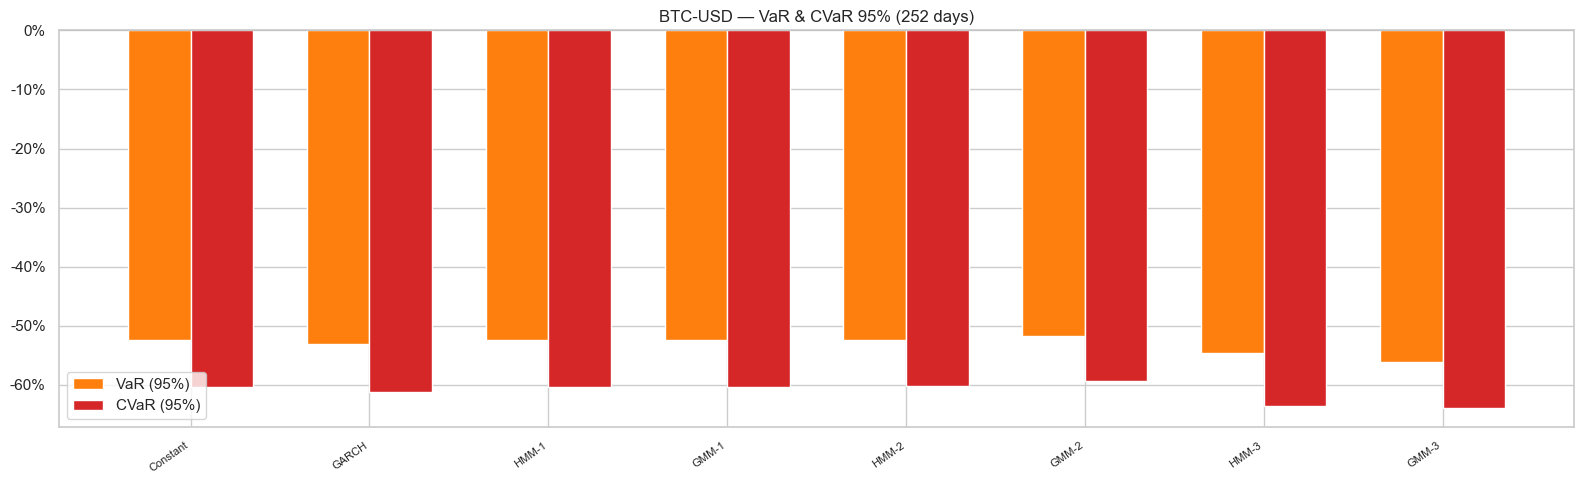

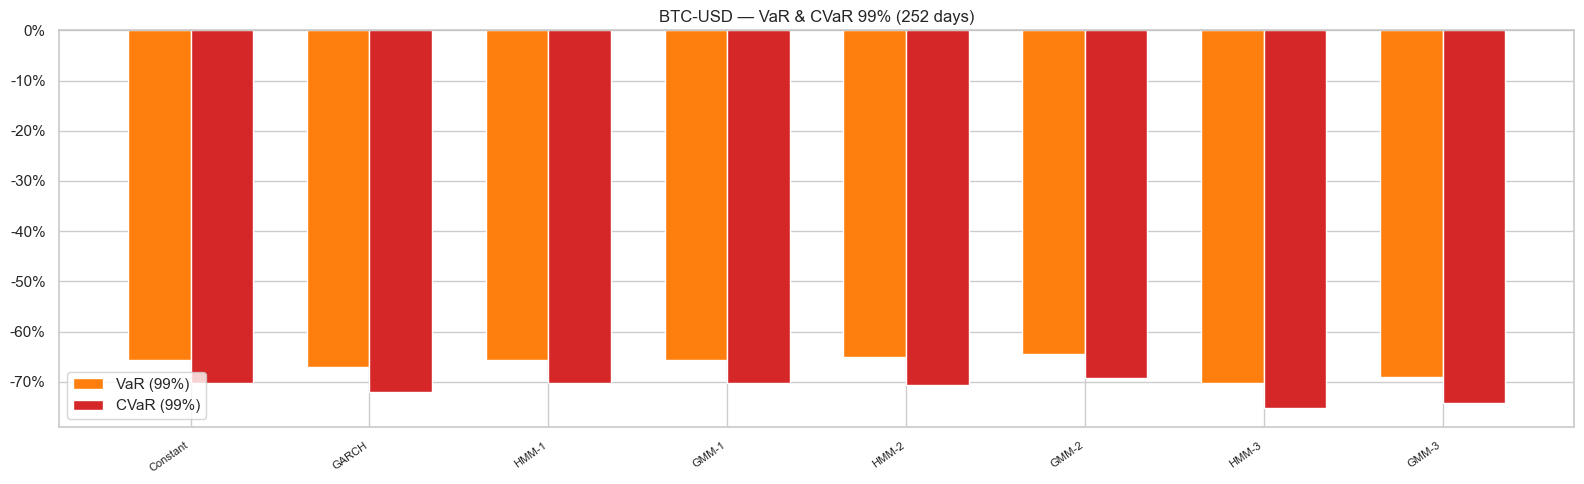

In [7]:
names = list(mc.keys())
x = np.arange(len(names))
width = 0.35

for conf, vk, ck in [("95%", "var_95", "cvar_95"), ("99%", "var_99", "cvar_99")]:
    fig, ax = plt.subplots(figsize=(16, 5))
    v = [mc[m][vk] for m in names]
    c = [mc[m][ck] for m in names]
    ax.bar(x - width/2, v, width, label=f"VaR ({conf})", color="#ff7f0e")
    ax.bar(x + width/2, c, width, label=f"CVaR ({conf})", color="#d62728")
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=35, ha="right", fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.set_title(f"{TICKER} — VaR & CVaR {conf} ({N_DAYS} days)")
    ax.legend()
    ax.axhline(0, color="gray", linewidth=0.5)
    plt.tight_layout()
    plt.show()

## 7. Final Price Distributions

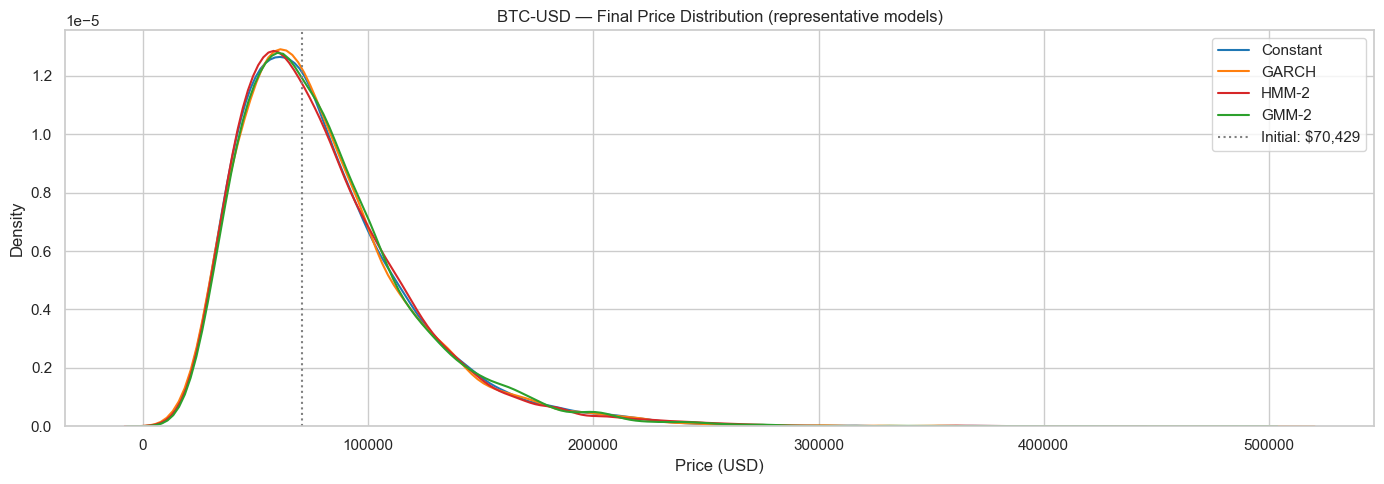

In [8]:
# Select representative models for readability
representative = ["Constant", "GARCH", "HMM-2", "GMM-2"]
rep_colors = ["#1f77b4", "#ff7f0e", "#d62728", "#2ca02c"]

fig, ax = plt.subplots(figsize=(14, 5))
for name, c in zip(representative, rep_colors):
    sns.kdeplot(mc[name]["fp"], ax=ax, label=name, color=c, linewidth=1.5)
ax.axvline(initial_price, color="gray", linewidth=1.5, linestyle=":", label=f"Initial: ${initial_price:,.0f}")
ax.set_title(f"{TICKER} — Final Price Distribution (representative models)")
ax.set_xlabel("Price (USD)")
ax.legend()
plt.tight_layout()
plt.show()

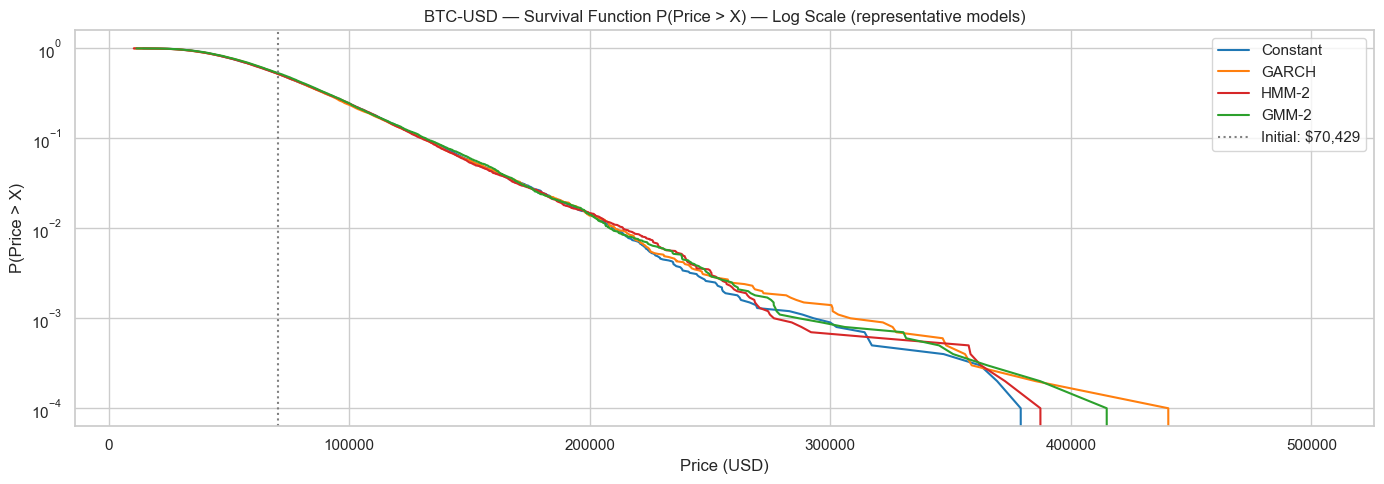

In [9]:
# Survival function (log-scale) — tail behavior
fig, ax = plt.subplots(figsize=(14, 5))
for name, c in zip(representative, rep_colors):
    sorted_p = np.sort(mc[name]["fp"])
    survival = 1 - np.arange(1, len(sorted_p) + 1) / len(sorted_p)
    ax.plot(sorted_p, survival, label=name, color=c, linewidth=1.5)
ax.axvline(initial_price, color="gray", linewidth=1.5, linestyle=":", label=f"Initial: ${initial_price:,.0f}")
ax.set_yscale("log")
ax.set_title(f"{TICKER} — Survival Function P(Price > X) — Log Scale (representative models)")
ax.set_xlabel("Price (USD)")
ax.set_ylabel("P(Price > X)")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Percentile Fan Chart

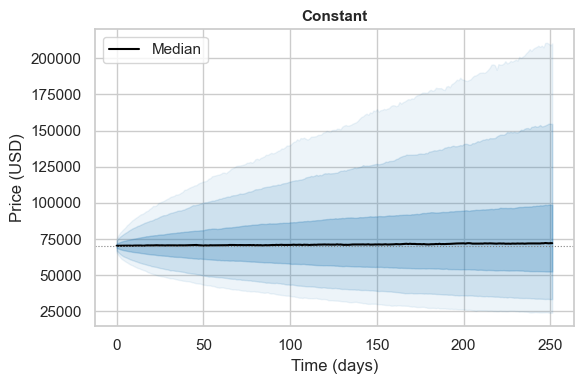

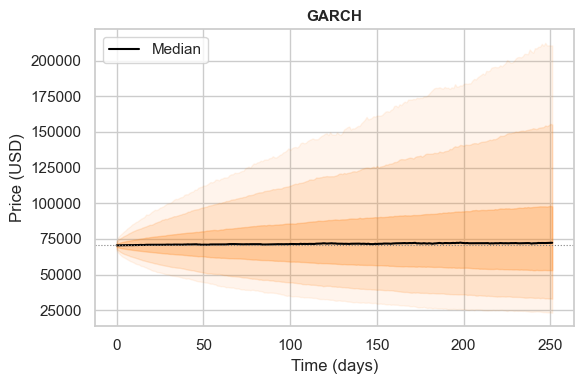

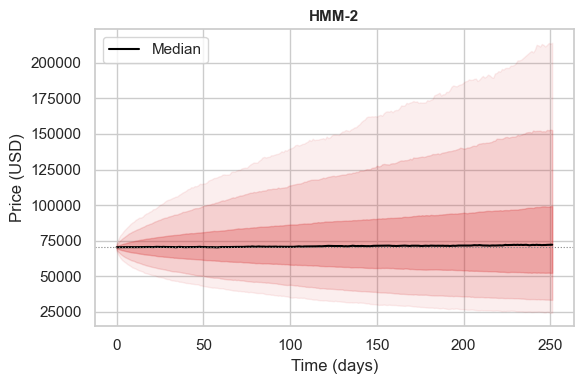

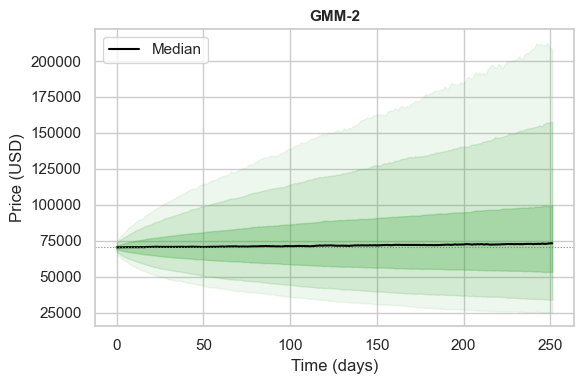

In [10]:
for name, c in zip(representative, rep_colors):
    fig, ax = plt.subplots(figsize=(6, 4))

    paths = mc[name]["paths"]

    p01 = paths.quantile(0.01, axis=1)
    p05 = paths.quantile(0.05, axis=1)
    p25 = paths.quantile(0.25, axis=1)
    p50 = paths.quantile(0.50, axis=1)
    p75 = paths.quantile(0.75, axis=1)
    p95 = paths.quantile(0.95, axis=1)
    p99 = paths.quantile(0.99, axis=1)

    x = paths.index

    ax.fill_between(x, p01, p99, color=c, alpha=0.08)
    ax.fill_between(x, p05, p95, color=c, alpha=0.15)
    ax.fill_between(x, p25, p75, color=c, alpha=0.25)
    ax.plot(x, p50, color="black", linewidth=1.5, label="Median")

    ax.axhline(initial_price, color="gray", linewidth=0.8, linestyle=":")
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Price (USD)")
    ax.legend()

    plt.tight_layout()
    plt.show()

## 9. Regime Count Study

How does increasing the number of regimes (1 → 2 → 3) affect VaR and CVaR for HMM and GMM?

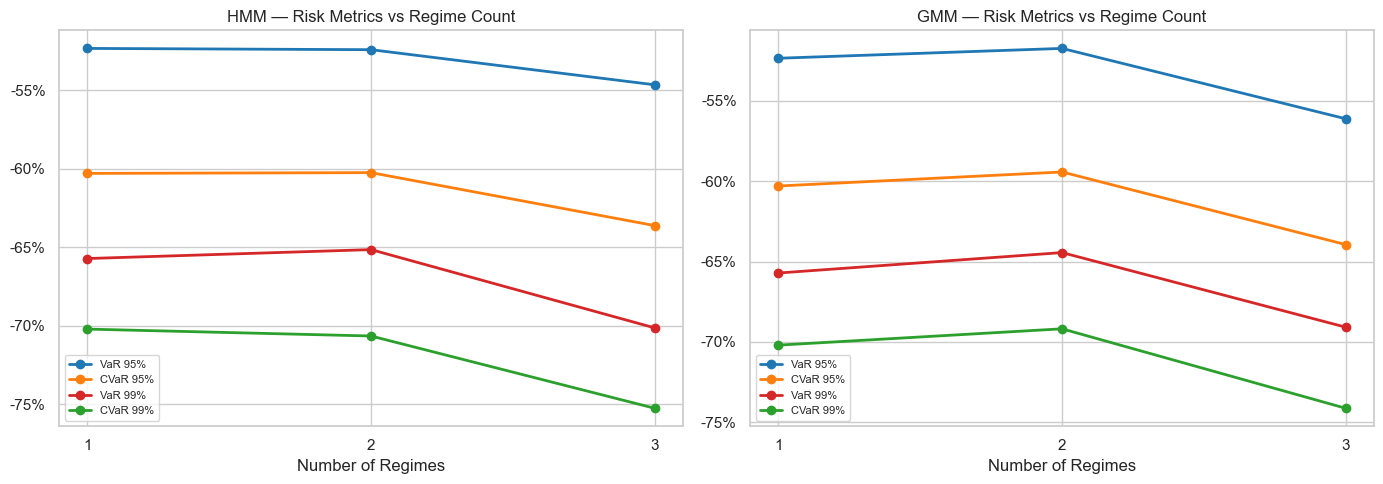

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics = ["var_95", "cvar_95", "var_99", "cvar_99"]
metric_labels = ["VaR 95%", "CVaR 95%", "VaR 99%", "CVaR 99%"]
colors = ["#1f77b4", "#ff7f0e", "#d62728", "#2ca02c"]

for ax, method in zip(axes, ["HMM", "GMM"]):
    regimes = [1, 2, 3]
    for metric, label, c in zip(metrics, metric_labels, colors):
        vals = [mc[f"{method}-{n}"][metric] for n in regimes]
        ax.plot(regimes, vals, marker="o", label=label, color=c, linewidth=2)
    ax.set_xticks(regimes)
    ax.set_xlabel("Number of Regimes")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.set_title(f"{method} — Risk Metrics vs Regime Count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 10. Transition Matrices

Regime transition probabilities for HMM and GMM with 2 and 3 regimes.

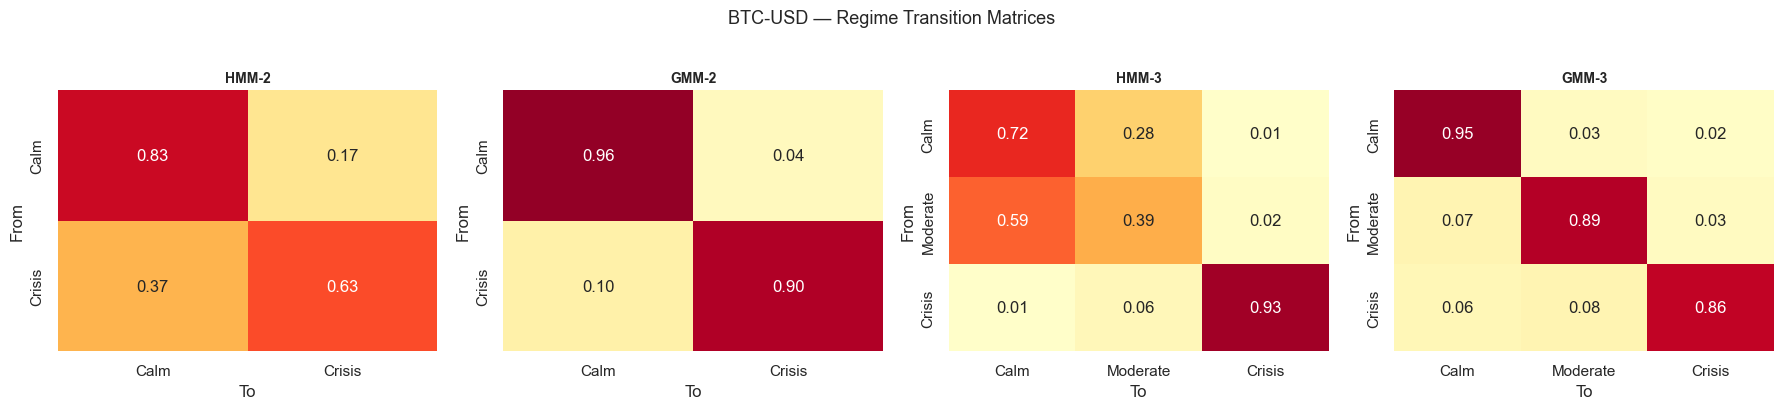

In [12]:
regime_names_map = {2: ["Calm", "Crisis"], 3: ["Calm", "Moderate", "Crisis"]}

def gmm_transition_matrix(labels, n_regimes):
    """Estimate transition matrix from observed label sequence."""
    counts = np.zeros((n_regimes, n_regimes))
    for i in range(len(labels) - 1):
        counts[labels[i], labels[i + 1]] += 1
    row_sums = counts.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return counts / row_sums

panels = []
for n in [2, 3]:
    panels.append(("HMM", n, hmm_fits[n]["transition_matrix"]))
    panels.append(("GMM", n, gmm_transition_matrix(gmm_fits[n]["regime_labels"], n)))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (method, n, tm) in zip(axes, panels):
    labels = regime_names_map[n]
    sns.heatmap(tm, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1,
                xticklabels=labels, yticklabels=labels, ax=ax, cbar=False)
    ax.set_title(f"{method}-{n}", fontsize=10, fontweight="bold")
    ax.set_xlabel("To")
    ax.set_ylabel("From")

fig.suptitle(f"{TICKER} — Regime Transition Matrices", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 11. Tail Risk — EVT & XGBoost Quantile Regression

Two non-MC approaches to VaR estimation:
- **EVT (GPD)**: fits a Generalized Pareto Distribution to tail exceedances — theoretically justified for extreme quantiles
- **XGB Quantile Regression**: predicts VaR directly via conditional quantile estimation — no distributional assumption. Hyperparameters selected via **TimeSeriesSplit CV** (pinball loss)

Both serve as audits of the parametric MC models above.

In [ ]:
# EVT analysis
evt = evt_summary(returns, confidence=0.99, threshold_quantile=0.95)
evt_95 = evt_summary(returns, confidence=0.95, threshold_quantile=0.95)

print(f"GPD fit: shape (xi) = {evt['shape']:.4f}, scale = {evt['scale']:.4f}")
print(f"Tail type: {evt['tail_type']}")
print(f"Threshold: {evt['threshold']:.4f} ({evt['n_exceedances']} exceedances / {evt['n_total']} obs)")
print()

# XGB quantile models (with temporal CV tuning)
xgb_05 = fit_quantile_model(returns, quantile=0.05, seed=SEED, tune=True)
xgb_01 = fit_quantile_model(returns, quantile=0.01, seed=SEED, tune=True)

if "best_params" in xgb_05:
    bp = xgb_05["best_params"]
    print(f"XGB tuned (95%): max_depth={bp['max_depth']}, lr={bp['learning_rate']}, n_estimators={bp['n_estimators']}")
if "best_params" in xgb_01:
    bp = xgb_01["best_params"]
    print(f"XGB tuned (99%): max_depth={bp['max_depth']}, lr={bp['learning_rate']}, n_estimators={bp['n_estimators']}")
print()

# Three-way comparison table
comparison = pd.DataFrame({
    "Normal": [f"{normal_var(returns, 0.95):.2%}", f"{normal_var(returns, 0.99):.2%}",
               f"{normal_cvar(returns, 0.95):.2%}", f"{normal_cvar(returns, 0.99):.2%}"],
    "EVT (GPD)": [f"{evt_95['evt_var']:.2%}", f"{evt['evt_var']:.2%}",
                  f"{evt_95['evt_cvar']:.2%}", f"{evt['evt_cvar']:.2%}"],
    "XGB Quantile": [f"{xgb_05['predicted_var']:.2%}", f"{xgb_01['predicted_var']:.2%}",
                     "—", "—"],
}, index=["VaR 95%", "VaR 99%", "CVaR 95%", "CVaR 99%"])

print("Parametric vs EVT vs ML — VaR Comparison:")
comparison

## 12. VaR Backtesting

Rolling-window validation: for each test day, fit the model on trailing data, predict 1-day VaR, and check if the actual return breached the threshold. A well-calibrated 95% VaR should be breached ~5% of the time.

Statistical tests:
- **Kupiec**: is the breach rate significantly different from expected?
- **Christoffersen**: are breaches independent (not clustered)?

Includes both MC-based models and EVT walk-forward backtesting.

In [ ]:
from src.analytics.backtesting import (
    compare_models, backtest_var, backtest_evt_var, backtest_summary,
    constant_fit, garch_fit, hmm_fit, gmm_fit,
)
from functools import partial

# Representative models — keep runtime reasonable with step=5, n_sims=2000
bt_configs = {
    "Constant": constant_fit,
    "GARCH": garch_fit,
    "HMM-2": partial(hmm_fit, n_regimes=2),
    "GMM-2": partial(gmm_fit, n_regimes=2),
}

print("Running model comparison (backtest all models)...")
comparison = compare_models(
    close, returns,
    model_configs=bt_configs,
    train_window=252, confidence=0.95, n_simulations=2_000, step=5, seed=SEED,
)
print(f"Best calibrated:   {comparison['best_calibrated']}")
print(f"Most conservative: {comparison['most_conservative']}")

# EVT walk-forward backtest
print("\nRunning EVT backtest...")
evt_bt = backtest_evt_var(returns, confidence=0.95, train_window=252, step=5)
evt_bt_sum = backtest_summary(evt_bt, confidence=0.95)
k_pass = "PASS" if evt_bt_sum["kupiec"]["pass"] else "FAIL"
c_pass = "PASS" if evt_bt_sum["christoffersen"]["pass"] else "FAIL"
print(f"EVT — Breach rate: {evt_bt_sum['breach_rate']:.1%} (expected 5%) | Kupiec: {k_pass} | Christoffersen: {c_pass}")

In [15]:
# Full comparison table with dual ranking
df_cmp = comparison["results"]
display_cols = ["n_obs", "n_breaches", "breach_rate", "expected_rate",
                "kupiec_p", "kupiec_pass", "christoffersen_p", "christoffersen_pass",
                "breach_error", "mean_predicted_var", "calibration_rank", "conservative_rank"]
fmt = df_cmp[display_cols].copy()
fmt["breach_rate"] = fmt["breach_rate"].map("{:.1%}".format)
fmt["expected_rate"] = fmt["expected_rate"].map("{:.1%}".format)
fmt["kupiec_p"] = fmt["kupiec_p"].map("{:.3f}".format)
fmt["christoffersen_p"] = fmt["christoffersen_p"].map("{:.3f}".format)
fmt["kupiec_pass"] = fmt["kupiec_pass"].map(lambda x: "PASS" if x else "FAIL")
fmt["christoffersen_pass"] = fmt["christoffersen_pass"].map(lambda x: "PASS" if x else "FAIL")
fmt["breach_error"] = fmt["breach_error"].map("{:.1%}".format)
fmt["mean_predicted_var"] = fmt["mean_predicted_var"].map("{:.4f}".format)
fmt

,n_obs,n_breaches,breach_rate,expected_rate,kupiec_p,kupiec_pass,christoffersen_p,christoffersen_pass,breach_error,mean_predicted_var,calibration_rank,conservative_rank
model,,,,,,,,,,,,
Constant,315,11,3.5%,5.0%,0.195,PASS,0.386,PASS,1.5%,-0.0513,3,1
GARCH,315,16,5.1%,5.0%,0.949,PASS,0.835,PASS,0.1%,-0.0448,1,3
HMM-2,315,26,8.3%,5.0%,0.015,FAIL,0.548,PASS,3.3%,-0.0364,4,4
GMM-2,315,16,5.1%,5.0%,0.949,PASS,0.234,PASS,0.1%,-0.0464,1,2


In [ ]:
# Actual returns vs predicted VaR — one chart per model
bt_colors = ["#1f77b4", "#ff7f0e", "#d62728", "#2ca02c"]

# Run individual backtests for per-window chart data
bt_chart_data = {}
for name, fit_fn in bt_configs.items():
    res = backtest_var(close, returns, fit_fn=fit_fn, train_window=252,
                       confidence=0.95, n_simulations=2_000, step=5, seed=SEED)
    bt_chart_data[name] = {"results": res, "summary": backtest_summary(res, 0.95)}

# Add EVT
bt_chart_data["EVT"] = {"results": evt_bt, "summary": evt_bt_sum}
bt_colors.append("#9467bd")

for (name, r), c in zip(bt_chart_data.items(), bt_colors):
    res = r["results"]
    s = r["summary"]
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(res.index, res["actual_return"], color="steelblue", linewidth=0.5, alpha=0.7, label="Actual return")
    ax.plot(res.index, res["predicted_var"], color="crimson", linewidth=1, linestyle="--", label="VaR 95%")
    breaches = res[res["breach"]]
    if len(breaches) > 0:
        ax.scatter(breaches.index, breaches["actual_return"], color="red", s=15, zorder=5, label=f"Breaches ({len(breaches)})")
    ax.axhline(0, color="gray", linewidth=0.5)
    k_label = "PASS" if s["kupiec"]["pass"] else "FAIL"
    c_label = "PASS" if s["christoffersen"]["pass"] else "FAIL"
    ax.set_title(f"{name} — Breach rate: {s['breach_rate']:.1%} (expected 5%) | Kupiec: {k_label} | Christoffersen: {c_label}",
                 fontsize=10, fontweight="bold")
    ax.set_ylabel("Daily Return")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 13. Key Takeaways

| Insight | Detail |
|---------|--------|
| **Constant vol underestimates tail risk** | Single σ ignores clustering and regime shifts — VaR/CVaR are the shallowest |
| **GARCH captures clustering** | Time-varying vol widens the fan in high-vol periods; persistence near 1.0 means shocks decay slowly |
| **Regime count matters** | Moving from 1→2 regimes adds a crisis state with higher σ; 3 regimes refine the calm–moderate–crisis split |
| **HMM vs GMM** | HMM learns transitions natively; GMM uses observed label sequences. Both produce similar risk estimates |
| **EVT is the gold standard for tails** | GPD fitted to exceedances gives theoretically justified extreme quantile estimates — more conservative than Normal at 99%+ |
| **EVT passes backtesting** | Walk-forward expanding-window validation confirms EVT VaR is well-calibrated out-of-sample |
| **XGB quantile regression audits parametric models** | ML predicts VaR directly without distributional assumptions. Where it disagrees with Normal/GARCH, the parametric assumption may be wrong |
| **Temporal CV prevents overfitting** | XGBoost hyperparameters selected via TimeSeriesSplit cross-validation — no look-ahead bias in model selection |
| **ML validates, doesn't replace** | XGBoost is used for nonparametric conditional VaR — an honest, additive role that avoids "ML for the sake of ML" |
| **Backtesting validates the models** | Kupiec tests breach rates; Christoffersen tests clustering. A model that "looks good" but fails backtesting is unreliable |